[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/1_MulticlassClassification_Iris_structured_data.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 14 (M2.3) - Iris: from two classes to three (softmax)

- Multiclass is a small step: output nodes = number of classes, activation = softmax, loss = categorical_crossentropy. That's the whole diff.
- TRAP: Iris is sorted alphabetically by class - shuffle (frac=1) + reset_index or your validation split sees ONE class. Great 60-second war story.
- Why 3 output nodes: we want a probability PER class. Softmax splits a probability mass of 1 across them; prediction = argmax, no 0.5 threshold.
- Dummy-encode y (3 columns) to match the 3 outputs.
-->

# Dense Neural Networks: Multiclass Classification
----------------------------------
**Dr. Dave Wanik**

Let's try to fit a dense neural network with the Iris dataset.

In [1]:
# for reading data
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

!pip install scikeras
from scikeras.wrappers import KerasClassifier # updated 2023

# from keras.utils import np_utils
from keras.utils import to_categorical

# for modeling
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

# useful link: https://shrikar.com/deep-learning-with-keras-and-python-for-multiclass-classification/
# useful link: https://machinelearningmastery.com/multi-class-classification-tutorial-keras-deep-learning-library/


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\dww05002\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# # read in the data
# url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/639388c2cbc2120a14dcf466e85730eb8be498bb/iris.csv'
# df = pd.read_csv(url)
# df.info()

In [3]:
# # read from shareable link
# # https://drive.google.com/file/d/1hcnnt2HJ6Iiv6yJJrk0thlPSibu_1q3x/view?usp=sharing
# !gdown 1hcnnt2HJ6Iiv6yJJrk0thlPSibu_1q3x
# df = pd.read_csv('../data/Iris.csv')

In [4]:
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/Iris.csv"

# retrieve the data and build a dataframe
df = pd.read_csv(url)

df.shape

(150, 5)

In [5]:
# show the head
df.head()

,sepal length,sepal width,petal length,petal width,iris
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# show counts per species
df['iris'].value_counts()

iris
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
# don't forget to shuffle! this way our data has some order...
df = df.sample(frac=1).reset_index(drop=True)
df.head()
# link: https://stackoverflow.com/questions/29576430/shuffle-dataframe-rows

,sepal length,sepal width,petal length,petal width,iris
0,4.9,3.1,1.5,0.1,Iris-setosa
1,6.3,2.5,5.0,1.9,Iris-virginica
2,4.8,3.1,1.6,0.2,Iris-setosa
3,6.3,2.9,5.6,1.8,Iris-virginica
4,5.1,3.5,1.4,0.3,Iris-setosa


In [8]:
# split into X and Y
Y = df['iris']
X = df.drop(['iris'], axis=1)

print(X.shape)
print(Y.shape)

(150, 4)
(150,)


In [9]:
# convert to numpy arrays
X = np.array(X)

In [10]:
# show Y
Y.head()

0       Iris-setosa
1    Iris-virginica
2       Iris-setosa
3    Iris-virginica
4       Iris-setosa
Name: iris, dtype: str

In [11]:
# work with labels
# encode class values as integers
encoder = LabelEncoder()
encoded_Y = encoder.fit_transform(Y)
# convert integers to dummy variables (i.e. one hot encoded)
dummy_y = to_categorical(encoded_Y)

In [12]:
encoded_Y

array([0, 2, 0, 2, 0, 1, 0, 2, 2, 1, 2, 1, 2, 1, 0, 1, 1, 2, 2, 1, 0, 1,
       0, 0, 0, 2, 0, 1, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1,
       2, 0, 2, 0, 1, 1, 1, 2, 1, 0, 1, 0, 0, 1, 1, 0, 0, 2, 0, 0, 0, 0,
       1, 2, 2, 1, 2, 1, 1, 0, 2, 1, 2, 1, 1, 0, 2, 2, 0, 0, 2, 0, 0, 1,
       2, 0, 0, 2, 1, 2, 1, 2, 0, 2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 0, 2, 1,
       2, 1, 2, 1, 0, 0, 0, 0, 1, 0, 2, 2, 2, 0, 0, 0, 1, 2, 0, 1, 1, 2,
       2, 2, 1, 2, 1, 1, 0, 2, 2, 2, 0, 2, 1, 2, 1, 2, 0, 2])

In [13]:
print(dummy_y.shape)
dummy_y

(150, 3)


array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0

## Train/Test Split - the honest yardstick

If we train on ALL the data and then grade the model on that same data, we graded it on questions it already saw. So BEFORE we build anything: lock 30% of the rows in a vault. The model never trains on them - they exist only to answer one question at the end... *does this thing generalize?*

In [14]:
# hold out a REAL test set - 30% goes in the vault
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, dummy_y,
                                                    test_size=0.3,
                                                    random_state=123)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(105, 4) (105, 3)
(45, 4) (45, 3)


In [15]:
# build a model
model = Sequential()
model.add(Dense(16, input_shape=(X.shape[1],), activation='relu')) # input shape is (features,)
model.add(Dense(3, activation='softmax')) # output
model.summary()

# make sure in a multiclass problem that you have one output node per target class
# and use a 'softmax' activation function which forces your model to split
# it's prediction among 3 classes (all adds up to 1)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# compile the model
model.compile(optimizer='rmsprop', # use rmsprop or Adam
              loss='categorical_crossentropy', # this is different instead of binary_crossentropy (for regular classification)
              metrics=['accuracy'])

In [17]:
# fit the model - on the TRAINING partition only!
history = model.fit(X_train,
                    y_train,
                    epochs=40,
                    batch_size=10,
                    validation_split=0.2, # last 20% of the TRAINING data used as validation
                    shuffle=True)

Epoch 1/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 6s 760ms/step - accuracy: 0.7000 - loss: 0.8109

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3452 - loss: 1.4090 - val_accuracy: 0.5714 - val_loss: 0.8898


Epoch 2/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2000 - loss: 1.6045

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3452 - loss: 1.1230 - val_accuracy: 0.5714 - val_loss: 0.8568


Epoch 3/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4000 - loss: 1.0902

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3810 - loss: 0.9621 - val_accuracy: 0.5238 - val_loss: 0.8541


Epoch 4/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2000 - loss: 0.9445

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5119 - loss: 0.8704 - val_accuracy: 0.6190 - val_loss: 0.8474


Epoch 5/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.8555

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6786 - loss: 0.8232 - val_accuracy: 0.6667 - val_loss: 0.8380


Epoch 6/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6000 - loss: 0.8587

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7500 - loss: 0.7895 - val_accuracy: 0.6667 - val_loss: 0.8368


Epoch 7/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8000 - loss: 0.7719

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7857 - loss: 0.7594 - val_accuracy: 0.5714 - val_loss: 0.8614


Epoch 8/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.5947

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7143 - loss: 0.7397 - val_accuracy: 0.6667 - val_loss: 0.8130


Epoch 9/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8000 - loss: 0.6506

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7857 - loss: 0.7201 - val_accuracy: 0.5714 - val_loss: 0.8386


Epoch 10/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.7144

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7143 - loss: 0.7009 - val_accuracy: 0.6667 - val_loss: 0.7837


Epoch 11/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8000 - loss: 0.6186

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7857 - loss: 0.6858 - val_accuracy: 0.5714 - val_loss: 0.7967


Epoch 12/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7000 - loss: 0.6530

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7500 - loss: 0.6735 - val_accuracy: 0.6667 - val_loss: 0.7637


Epoch 13/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8000 - loss: 0.6291

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7857 - loss: 0.6561 - val_accuracy: 0.5714 - val_loss: 0.7882


Epoch 14/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8000 - loss: 0.6569

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7619 - loss: 0.6455 - val_accuracy: 0.6667 - val_loss: 0.7336


Epoch 15/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7000 - loss: 0.6517

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7976 - loss: 0.6332 - val_accuracy: 0.6190 - val_loss: 0.7438


Epoch 16/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.6228

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8095 - loss: 0.6198 - val_accuracy: 0.6190 - val_loss: 0.7373


Epoch 17/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6888

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8095 - loss: 0.6084 - val_accuracy: 0.6667 - val_loss: 0.6980


Epoch 18/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.5663

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8452 - loss: 0.5950 - val_accuracy: 0.6667 - val_loss: 0.6990


Epoch 19/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.6251

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8214 - loss: 0.5829 - val_accuracy: 0.7619 - val_loss: 0.6581


Epoch 20/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8000 - loss: 0.6645

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8095 - loss: 0.5787 - val_accuracy: 0.6667 - val_loss: 0.6782


Epoch 21/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.5995

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8452 - loss: 0.5623 - val_accuracy: 0.6667 - val_loss: 0.6768


Epoch 22/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.4906

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8571 - loss: 0.5548 - val_accuracy: 0.6667 - val_loss: 0.6726


Epoch 23/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8000 - loss: 0.5563

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8333 - loss: 0.5457 - val_accuracy: 0.6667 - val_loss: 0.6632


Epoch 24/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8000 - loss: 0.6232

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8452 - loss: 0.5332 - val_accuracy: 0.7143 - val_loss: 0.6184


Epoch 25/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.5725

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8690 - loss: 0.5278 - val_accuracy: 0.6667 - val_loss: 0.6571


Epoch 26/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9000 - loss: 0.3728

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8452 - loss: 0.5166 - val_accuracy: 0.6667 - val_loss: 0.6244


Epoch 27/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.5042

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.5079 - val_accuracy: 0.6667 - val_loss: 0.6090


Epoch 28/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7000 - loss: 0.5447

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8810 - loss: 0.4974 - val_accuracy: 0.6667 - val_loss: 0.6022


Epoch 29/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.5051

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9167 - loss: 0.4917 - val_accuracy: 0.6667 - val_loss: 0.6146


Epoch 30/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9000 - loss: 0.5040

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8333 - loss: 0.4823 - val_accuracy: 0.8095 - val_loss: 0.5609


Epoch 31/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.5996

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.4754 - val_accuracy: 0.8095 - val_loss: 0.5556


Epoch 32/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8000 - loss: 0.4702

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.4686 - val_accuracy: 0.7619 - val_loss: 0.5655


Epoch 33/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9000 - loss: 0.3834

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8810 - loss: 0.4610 - val_accuracy: 0.6667 - val_loss: 0.5716


Epoch 34/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8000 - loss: 0.5437

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8929 - loss: 0.4552 - val_accuracy: 0.8095 - val_loss: 0.5206


Epoch 35/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.5029

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9405 - loss: 0.4475 - val_accuracy: 0.7619 - val_loss: 0.5413


Epoch 36/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.3478

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9286 - loss: 0.4413 - val_accuracy: 0.6667 - val_loss: 0.5639


Epoch 37/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8000 - loss: 0.4325

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8810 - loss: 0.4383 - val_accuracy: 0.8095 - val_loss: 0.5128


Epoch 38/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9000 - loss: 0.4657

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9286 - loss: 0.4327 - val_accuracy: 0.8095 - val_loss: 0.4890


Epoch 39/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.4608

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9405 - loss: 0.4296 - val_accuracy: 0.8095 - val_loss: 0.4977


Epoch 40/40


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.5380

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8929 - loss: 0.4194 - val_accuracy: 0.8095 - val_loss: 0.4670


🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 15 (M2.3) - Iris: fit, early stopping, and honest evaluation

- categorical_crossentropy, NOT binary - the #1 student mistake in this module. Say it twice.
- Early stopping on val_loss, patience 10, restore best weights.
- Accuracy hits 1.0 - and that's the moment to get suspicious (M1 reflex: too good = check yourself). It holds here because Iris is tiny and easy, but PROVE it with a real train/test holdout - and this notebook now DOES: fit on X_train, confusion matrix on X_test the model never saw.
- argmax the predictions into a confusion matrix - clean diagonal.
-->

## Callbacks (Early Stopping, return best weights, patience)
Remember that you will just use early_stopping in the future - no need to hard-code epochs.

In [18]:
# we will keep the same model architecture as before,
# but we will make this a little simpler...

import keras
from keras.callbacks import EarlyStopping

# fresh start! clear the old model and rebuild from scratch
# gotcha: re-running fit on an existing model CONTINUES training from
# wherever it left off... great for resuming, terrible for a fair comparison!
keras.backend.clear_session()

model = Sequential()
model.add(Dense(16, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# early stopping callback
# This callback will stop the training when there is no improvement in
# the validation loss for 10 consecutive epochs.
es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                   mode='min',
                                   patience=10, # you can play with this!
                                   restore_best_weights=True) # important - otherwise you just return the last weigths...

# now we just update our model fit call
history = model.fit(X_train,
                    y_train,
                    callbacks=[es],
                    epochs=1000000, # you can set this to a big number!
                    batch_size=10,
                    shuffle=True,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 5s 685ms/step - accuracy: 0.2000 - loss: 2.8228

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.3571 - loss: 2.0590 - val_accuracy: 0.1429 - val_loss: 2.3617


Epoch 2/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 2.7547

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3571 - loss: 1.6912 - val_accuracy: 0.1429 - val_loss: 1.9529


Epoch 3/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 1.1626

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3571 - loss: 1.4357 - val_accuracy: 0.1429 - val_loss: 1.6303


Epoch 4/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3000 - loss: 1.4585

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3571 - loss: 1.2608 - val_accuracy: 0.1429 - val_loss: 1.4068


Epoch 5/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3000 - loss: 1.2608

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3571 - loss: 1.1394 - val_accuracy: 0.1429 - val_loss: 1.2326


Epoch 6/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6000 - loss: 0.8644

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3571 - loss: 1.0576 - val_accuracy: 0.1429 - val_loss: 1.1410


Epoch 7/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3000 - loss: 1.0518

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3571 - loss: 0.9986 - val_accuracy: 0.1429 - val_loss: 1.0510


Epoch 8/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6000 - loss: 0.8666

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3810 - loss: 0.9575 - val_accuracy: 0.1905 - val_loss: 1.0104


Epoch 9/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3000 - loss: 0.8999

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3810 - loss: 0.9198 - val_accuracy: 0.3810 - val_loss: 0.9725


Epoch 10/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6000 - loss: 0.7820

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4405 - loss: 0.8866 - val_accuracy: 0.6190 - val_loss: 0.9255


Epoch 11/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6000 - loss: 0.9064

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7262 - loss: 0.8584 - val_accuracy: 0.8095 - val_loss: 0.8896


Epoch 12/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9000 - loss: 0.8358

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8571 - loss: 0.8373 - val_accuracy: 0.9048 - val_loss: 0.8675


Epoch 13/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.8211

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9048 - loss: 0.8126 - val_accuracy: 0.9524 - val_loss: 0.8504


Epoch 14/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9000 - loss: 0.7648

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8929 - loss: 0.7885 - val_accuracy: 0.9524 - val_loss: 0.8363


Epoch 15/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9000 - loss: 0.7411

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.7655 - val_accuracy: 0.7619 - val_loss: 0.8419


Epoch 16/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8000 - loss: 0.7413

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7976 - loss: 0.7477 - val_accuracy: 0.8571 - val_loss: 0.8160


Epoch 17/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6000 - loss: 0.7593

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8571 - loss: 0.7272 - val_accuracy: 0.8571 - val_loss: 0.7934


Epoch 18/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.7475

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8810 - loss: 0.7091 - val_accuracy: 0.9524 - val_loss: 0.7706


Epoch 19/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8000 - loss: 0.6855

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8571 - loss: 0.6904 - val_accuracy: 0.9524 - val_loss: 0.7321


Epoch 20/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.6418

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8690 - loss: 0.6736 - val_accuracy: 0.9048 - val_loss: 0.7127


Epoch 21/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.6695

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9643 - loss: 0.6593 - val_accuracy: 0.8571 - val_loss: 0.7388


Epoch 22/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.5975

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8452 - loss: 0.6420 - val_accuracy: 0.9048 - val_loss: 0.7208


Epoch 23/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7000 - loss: 0.7229

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8571 - loss: 0.6296 - val_accuracy: 0.7619 - val_loss: 0.7215


Epoch 24/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8000 - loss: 0.5664

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7857 - loss: 0.6108 - val_accuracy: 0.9524 - val_loss: 0.6635


Epoch 25/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9000 - loss: 0.5958

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8810 - loss: 0.6038 - val_accuracy: 0.9524 - val_loss: 0.6597


Epoch 26/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9000 - loss: 0.5971

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.5866 - val_accuracy: 0.8095 - val_loss: 0.6858


Epoch 27/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7000 - loss: 0.6666

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8214 - loss: 0.5791 - val_accuracy: 0.9524 - val_loss: 0.6476


Epoch 28/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.4253

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9048 - loss: 0.5654 - val_accuracy: 0.9048 - val_loss: 0.6529


Epoch 29/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.4338

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8690 - loss: 0.5516 - val_accuracy: 0.9524 - val_loss: 0.6346


Epoch 30/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8000 - loss: 0.5997

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9167 - loss: 0.5414 - val_accuracy: 0.8095 - val_loss: 0.6426


Epoch 31/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9000 - loss: 0.4629

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8690 - loss: 0.5336 - val_accuracy: 0.8095 - val_loss: 0.6354


Epoch 32/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9000 - loss: 0.4132

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8690 - loss: 0.5209 - val_accuracy: 0.9524 - val_loss: 0.5999


Epoch 33/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8000 - loss: 0.5761

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9405 - loss: 0.5089 - val_accuracy: 0.8095 - val_loss: 0.6115


Epoch 34/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9000 - loss: 0.3874

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8452 - loss: 0.5035 - val_accuracy: 0.9524 - val_loss: 0.5635


Epoch 35/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.4622

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9524 - loss: 0.4905 - val_accuracy: 0.9524 - val_loss: 0.5632


Epoch 36/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8000 - loss: 0.5754

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9524 - loss: 0.4802 - val_accuracy: 0.9524 - val_loss: 0.5514


Epoch 37/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.5813

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9524 - loss: 0.4691 - val_accuracy: 0.9524 - val_loss: 0.5367


Epoch 38/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9000 - loss: 0.4561

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9524 - loss: 0.4605 - val_accuracy: 0.9524 - val_loss: 0.5327


Epoch 39/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9000 - loss: 0.4235

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9524 - loss: 0.4525 - val_accuracy: 0.9524 - val_loss: 0.5422


Epoch 40/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9000 - loss: 0.3751

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9167 - loss: 0.4445 - val_accuracy: 0.9524 - val_loss: 0.5150


Epoch 41/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8000 - loss: 0.4747

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9524 - loss: 0.4384 - val_accuracy: 0.9524 - val_loss: 0.4836


Epoch 42/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9000 - loss: 0.4996

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9524 - loss: 0.4273 - val_accuracy: 0.9524 - val_loss: 0.4809


Epoch 43/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.3975

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9643 - loss: 0.4199 - val_accuracy: 0.9524 - val_loss: 0.4735


Epoch 44/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8000 - loss: 0.4368

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9405 - loss: 0.4128 - val_accuracy: 0.9524 - val_loss: 0.4733


Epoch 45/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.3338

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.4069 - val_accuracy: 0.9524 - val_loss: 0.4590


Epoch 46/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.4714

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9286 - loss: 0.4014 - val_accuracy: 0.9524 - val_loss: 0.4390


Epoch 47/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.3179

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9524 - loss: 0.3923 - val_accuracy: 0.9524 - val_loss: 0.4304


Epoch 48/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.3336

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.3827 - val_accuracy: 0.9524 - val_loss: 0.4411


Epoch 49/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9000 - loss: 0.4131

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9405 - loss: 0.3808 - val_accuracy: 0.9524 - val_loss: 0.4133


Epoch 50/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9000 - loss: 0.2769

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9524 - loss: 0.3733 - val_accuracy: 0.9524 - val_loss: 0.4038


Epoch 51/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.3979

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.3686 - val_accuracy: 0.9524 - val_loss: 0.4052


Epoch 52/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.2878

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9881 - loss: 0.3623 - val_accuracy: 0.9524 - val_loss: 0.4055


Epoch 53/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.3265

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9762 - loss: 0.3546 - val_accuracy: 0.9524 - val_loss: 0.4147


Epoch 54/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.3375

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9643 - loss: 0.3509 - val_accuracy: 0.9524 - val_loss: 0.3878


Epoch 55/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.3286

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.3488 - val_accuracy: 0.9524 - val_loss: 0.3943


Epoch 56/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.3438

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9524 - loss: 0.3423 - val_accuracy: 0.9524 - val_loss: 0.3661


Epoch 57/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.3158

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.3378 - val_accuracy: 0.9524 - val_loss: 0.3597


Epoch 58/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.2908

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.3344 - val_accuracy: 0.9524 - val_loss: 0.3500


Epoch 59/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.3042

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.3298 - val_accuracy: 0.9524 - val_loss: 0.3622


Epoch 60/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.3190

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.3253 - val_accuracy: 0.9524 - val_loss: 0.3737


Epoch 61/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.3465

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.3182 - val_accuracy: 0.9524 - val_loss: 0.3744


Epoch 62/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.3248

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9643 - loss: 0.3171 - val_accuracy: 0.9524 - val_loss: 0.3446


Epoch 63/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.2897

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9643 - loss: 0.3121 - val_accuracy: 0.9524 - val_loss: 0.3614


Epoch 64/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8000 - loss: 0.4684

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9643 - loss: 0.3091 - val_accuracy: 0.9524 - val_loss: 0.3587


Epoch 65/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.3930

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.3043 - val_accuracy: 0.9524 - val_loss: 0.3498


Epoch 66/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.2498

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9881 - loss: 0.2972 - val_accuracy: 0.9524 - val_loss: 0.3145


Epoch 67/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.2100

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9524 - loss: 0.2979 - val_accuracy: 0.9524 - val_loss: 0.3098


Epoch 68/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.2469

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9762 - loss: 0.2935 - val_accuracy: 0.9524 - val_loss: 0.3438


Epoch 69/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9000 - loss: 0.3747

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9524 - loss: 0.2874 - val_accuracy: 0.9524 - val_loss: 0.3326


Epoch 70/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.2470

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9643 - loss: 0.2845 - val_accuracy: 0.9524 - val_loss: 0.3082


Epoch 71/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.2226

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2836 - val_accuracy: 0.9524 - val_loss: 0.3214


Epoch 72/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.2135

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9643 - loss: 0.2786 - val_accuracy: 0.9524 - val_loss: 0.3107


Epoch 73/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.3037

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9643 - loss: 0.2735 - val_accuracy: 0.9524 - val_loss: 0.2863


Epoch 74/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.2485

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2741 - val_accuracy: 0.9524 - val_loss: 0.3054


Epoch 75/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.2532

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2671 - val_accuracy: 0.9524 - val_loss: 0.2947


Epoch 76/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1604

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.2652 - val_accuracy: 0.9524 - val_loss: 0.3043


Epoch 77/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.2047

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9881 - loss: 0.2611 - val_accuracy: 0.9524 - val_loss: 0.2918


Epoch 78/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.3279

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2578 - val_accuracy: 0.9524 - val_loss: 0.2947


Epoch 79/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.3449

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2577 - val_accuracy: 0.9524 - val_loss: 0.2994


Epoch 80/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.2578

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2508 - val_accuracy: 0.9524 - val_loss: 0.2656


Epoch 81/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.2220

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9881 - loss: 0.2505 - val_accuracy: 0.9524 - val_loss: 0.2853


Epoch 82/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.2197

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9643 - loss: 0.2479 - val_accuracy: 0.9524 - val_loss: 0.2701


Epoch 83/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.2387

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2455 - val_accuracy: 0.9524 - val_loss: 0.2787


Epoch 84/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 0.2236

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2406 - val_accuracy: 0.9524 - val_loss: 0.3033


Epoch 85/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.3147

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9643 - loss: 0.2420 - val_accuracy: 0.9524 - val_loss: 0.2979


Epoch 86/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.1839

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.2385 - val_accuracy: 0.9524 - val_loss: 0.2680


Epoch 87/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9000 - loss: 0.3529

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.2332 - val_accuracy: 0.9524 - val_loss: 0.2661


Epoch 88/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.3008

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.2333 - val_accuracy: 0.9524 - val_loss: 0.2414


Epoch 89/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.1918

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2284 - val_accuracy: 0.9524 - val_loss: 0.2646


Epoch 90/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.3541

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9881 - loss: 0.2273 - val_accuracy: 0.9524 - val_loss: 0.2589


Epoch 91/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1873

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.2252 - val_accuracy: 0.9524 - val_loss: 0.2551


Epoch 92/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.2460

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2225 - val_accuracy: 0.9524 - val_loss: 0.2436


Epoch 93/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.3328

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9881 - loss: 0.2206 - val_accuracy: 0.9524 - val_loss: 0.2342


Epoch 94/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.2360

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2155 - val_accuracy: 0.9524 - val_loss: 0.2462


Epoch 95/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.2375

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9643 - loss: 0.2137 - val_accuracy: 0.9524 - val_loss: 0.2190


Epoch 96/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1409

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.2131 - val_accuracy: 0.9524 - val_loss: 0.2346


Epoch 97/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.1819

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9643 - loss: 0.2081 - val_accuracy: 0.9524 - val_loss: 0.2316


Epoch 98/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1967

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9881 - loss: 0.2072 - val_accuracy: 0.9524 - val_loss: 0.2233


Epoch 99/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.2205

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2071 - val_accuracy: 0.9524 - val_loss: 0.2096


Epoch 100/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.1678

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.2039 - val_accuracy: 0.9524 - val_loss: 0.2303


Epoch 101/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.2709

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9881 - loss: 0.2041 - val_accuracy: 0.9524 - val_loss: 0.2220


Epoch 102/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1011

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.2001 - val_accuracy: 0.9524 - val_loss: 0.1992


Epoch 103/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.1193

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.1977 - val_accuracy: 0.9524 - val_loss: 0.2085


Epoch 104/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1701

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.1979 - val_accuracy: 0.9524 - val_loss: 0.1947


Epoch 105/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1504

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9762 - loss: 0.1947 - val_accuracy: 0.9524 - val_loss: 0.1900


Epoch 106/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.1831

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9762 - loss: 0.1925 - val_accuracy: 0.9524 - val_loss: 0.1955


Epoch 107/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.1693

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9643 - loss: 0.1934 - val_accuracy: 0.9524 - val_loss: 0.1998


Epoch 108/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9000 - loss: 0.2152

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.1880 - val_accuracy: 0.9524 - val_loss: 0.1920


Epoch 109/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9000 - loss: 0.3422

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.1870 - val_accuracy: 0.9524 - val_loss: 0.1994


Epoch 110/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.1712

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.1888 - val_accuracy: 0.9524 - val_loss: 0.1772


Epoch 111/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9000 - loss: 0.2522

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.1853 - val_accuracy: 0.9524 - val_loss: 0.1857


Epoch 112/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1654

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9762 - loss: 0.1813 - val_accuracy: 0.9524 - val_loss: 0.2005


Epoch 113/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9000 - loss: 0.3468

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9881 - loss: 0.1817 - val_accuracy: 0.9524 - val_loss: 0.1889


Epoch 114/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.1540

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9762 - loss: 0.1794 - val_accuracy: 0.9524 - val_loss: 0.1969


Epoch 115/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1429

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9881 - loss: 0.1776 - val_accuracy: 0.9524 - val_loss: 0.1852


Epoch 116/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.1930

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.1767 - val_accuracy: 0.9524 - val_loss: 0.1853


Epoch 117/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.1933

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - loss: 0.1760 - val_accuracy: 0.9524 - val_loss: 0.1811


Epoch 118/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.2289

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9762 - loss: 0.1748 - val_accuracy: 0.9524 - val_loss: 0.1839


Epoch 119/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.2339

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9881 - loss: 0.1717 - val_accuracy: 0.9524 - val_loss: 0.1846


Epoch 120/1000000


1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1030

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9762 - loss: 0.1706 - val_accuracy: 0.9524 - val_loss: 0.1842


## Evaluate The Model

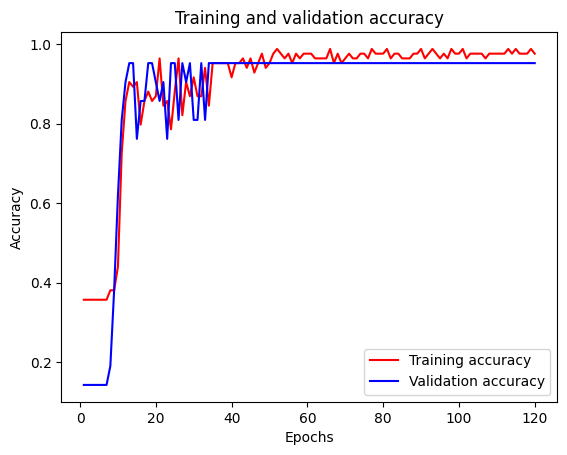

In [19]:
# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, acc, 'r', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

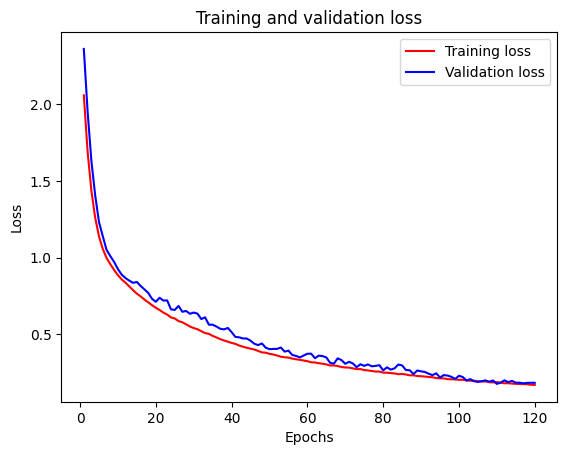

In [20]:
# learning curve
import matplotlib.pyplot as plt

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# see how the model did - ON DATA IT HAS NEVER SEEN!
preds = model.predict(X_test)
print(preds.shape)

# i'm spreading that prediction across three nodes and they sum to 1
print(preds[0])

# sum it up! see how probability mass (1) is spread over three preds?
np.sum(preds[0])

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


(45, 3)
[0.00702652 0.78896886 0.20400466]


np.float32(1.0)

In [22]:
# here is y_test - still one-hot encoded
y_test

array([[0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [23]:
# here is what argmax does
y_test.argmax(axis=1)

array([1, 2, 2, 2, 2, 0, 1, 0, 2, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 0, 1, 2,
       0, 2, 2, 0, 1, 2, 0, 0, 1, 0, 2, 0, 0, 2, 2, 1, 1, 0, 0, 0, 2, 2,
       0])

In [24]:
preds

array([[7.02651776e-03, 7.88968861e-01, 2.04004660e-01],
       [1.46550665e-04, 4.81485069e-01, 5.18368363e-01],
       [2.58106389e-04, 2.48439267e-01, 7.51302660e-01],
       [3.15076504e-05, 9.59680602e-02, 9.04000461e-01],
       [5.06773176e-06, 4.15444262e-02, 9.58450496e-01],
       [9.98163283e-01, 1.83506985e-03, 1.69754242e-06],
       [3.57397576e-03, 6.01093829e-01, 3.95332128e-01],
       [9.91424024e-01, 8.55553802e-03, 2.04930711e-05],
       [8.90566844e-06, 4.97349016e-02, 9.50256169e-01],
       [9.82925534e-01, 1.70227494e-02, 5.17232729e-05],
       [1.88912483e-04, 1.97307333e-01, 8.02503765e-01],
       [5.84676024e-03, 8.81868184e-01, 1.12285063e-01],
       [9.82701838e-01, 1.72495432e-02, 4.86652643e-05],
       [9.79916811e-01, 2.00286396e-02, 5.46050069e-05],
       [3.86423199e-04, 2.11119220e-01, 7.88494289e-01],
       [9.94283617e-01, 5.70719503e-03, 9.16129284e-06],
       [5.31637808e-04, 5.61434448e-01, 4.38033909e-01],
       [7.36760208e-03, 7.29284

In [25]:
preds.argmax(axis=1)

array([1, 2, 2, 2, 2, 0, 1, 0, 2, 0, 2, 1, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2,
       0, 2, 2, 0, 1, 2, 0, 0, 1, 0, 2, 0, 0, 2, 2, 1, 1, 0, 0, 0, 2, 2,
       0])

In [26]:
# here it is! almost a perfect prediction
# actual is left, predicted is top
# names can be found by inspecting Y
matrix = confusion_matrix(y_test.argmax(axis=1), preds.argmax(axis=1))
matrix

array([[19,  0,  0],
       [ 0,  9,  0],
       [ 0,  1, 16]])

In [27]:
# more detail on how well things were predicted
print(classification_report(y_test.argmax(axis=1), preds.argmax(axis=1)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.90      1.00      0.95         9
           2       1.00      0.94      0.97        17

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



# On Your Own
Like I say at the end of the video - your job as a data scientist is to help people believe in your model. You need to make sure folks don't doubt your work!

This notebook now does it the RIGHT way: we fit on `X_train` (with a val_split of 0.2 carved out of the training partition as a feedback signal), and the confusion matrix + classification report are computed on `X_test` - rows the model has NEVER seen. This is the way to do it for any type of DL project!

Now push it further:
* Change `test_size` to 0.5 and re-run. With only 75 training rows, does the model still nail the test set?
* Add `stratify=encoded_Y` to the split so each partition gets the same class mix - then check `y_test.argmax(axis=1)` counts to prove it.
* Change the `random_state` and re-run a few times. How much do your test metrics wiggle? (That wiggle is exactly why k-fold cross-validation exists... more on that soon!)

# Other key take-aways
* Note that you had to use a LabelEncoder() here and that it sorted the categories in alphabetical order and then encoded them inplace with 0, 1, 2
* You had to make dummy variables for Y (and you didn't need to do this for binary classification problems - this is because in binary classification you had 2 categories and one output node with a SIGMOID activation function which made predictions between 0 and 1).
* The output node of your neural network had 3 nodes - why? Because you have three types of flowers that you are trying to predict. Note that you are using a softmax instead of a sigmoid activation function.
  * You also are using `categorical_crossentropy` to split the predicted probability mass among your N categories.